In [1]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.optimize import curve_fit
from scipy.spatial import ConvexHull

In [2]:
# Set the global font size to 7 pt
plt.rcParams.update({
    'font.size': 7,              # Global font size
    'axes.titlesize': 7,          # Axes title font size
    'axes.labelsize': 7,          # Axis label font size
    'xtick.labelsize': 7,         # X-axis tick font size
    'ytick.labelsize': 7,         # Y-axis tick font size
    'legend.fontsize': 7,         # Legend font size
    'figure.titlesize': 7,        # Figure title font size
})
plt.rcParams['axes.unicode_minus'] = False  # Render minus signs correctly
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']  # Add fallback fonts here if Arial is unavailable

cm_to_inch = 1 / 2.54
length = width = 7
figsize_cm = (length * cm_to_inch, width * cm_to_inch)  # (9cm, 9cm)
args = {"alpha":0.7, "s":25,"zorder":10}
args1 = {"alpha":0.7,"s":30, "facecolors":'none',"edgecolors":'red',"zorder":10}
step_args = {"where":'pre',"color":'red', "alpha":0.6,"linewidth":2.5,"zorder":0}
grad_args = {}

In [3]:
def identify_2d_front_ops(f1, f2, ops1 = lambda x,y:x>y, ops2 = lambda x,y:x>y):
    length = len(f1)
    front_indics = []
    for i in range(length):
        is_front = True
        for j in range(length):
            if i != j and ops1(f1[i],f1[j]) and ops2(f2[i],f2[j]):
                is_front = False
                    
        if is_front:
            front_indics.append(i)
    return f1[front_indics], f2[front_indics]

def sorted_front(f1,f2,ops = '>', extend_t = ()):
    t_f12 = zip(f1,f2)
    reverse = False
    if ops == '>': 
        reverse = True
    s_f12_sorted = sorted(t_f12, key=lambda x: x[0], reverse=reverse)
    
    return [i[0] for i in s_f12_sorted], [i[1] for i in s_f12_sorted]

def identify_2d_front(f1, f2):
    length = len(f1)
    front_indics = []
    for i in range(length):
        is_front = True
        for j in range(length):
            if i != j and f1[j] >= f1[i] and f2[j] >= f2[i]:
                is_front = False
                    
        if is_front:
            front_indics.append(i)
    return f1[front_indics], f2[front_indics]
def identify_pareto_front_3d(f1, f2, f3):
    front_indics = []
    for i in range(len(f1)):
        is_front = True
        for j in range(len(f1)):
            if i != j and f1[i] >= f1[j] and f2[i] >= f2[j] and f3[i] <= f3[j]:
                is_front = False
        if is_front:
            front_indics.append(i)
    return front_indics 
def fit_2d_front(f1, f2, deg = 2):
    med = np.median(f1)
    
    poly = np.polyfit(f1, f2, deg)
    parameter = poly
    p = np.poly1d(parameter)
    
    f1_fitted = np.arange(np.min(f1),np.max(f1),0.0001)
    f2_fitted = p(f1_fitted)

    # plt.plot(f1_fitted , f2_fitted, 'r--')
    # f1_fitted = np.concatenate([f1_fitted_1, f1_fitted_2], axis=0)
    # f2_fitted = np.concatenate([f2_fitted_1, f2_fitted_2], axis=0)
    
    return f1_fitted,f2_fitted
    
def plot_2d(f1, f2, express, method, file = None, deg = 3, tight_layout = True, title = 'Pareto front of the Round 1', labels = None):
    # Create the base figure
    ax = plt.figure(figsize=figsize_cm)
    
    plt.xlabel(r'TM-score ($\!\!\uparrow\!\!$)')
    plt.ylabel(r'Solubility ($\!\!\uparrow\!\!$)')
    
    # Prepare index groups for plotting
    indics_selected = [i for i in range(len(express)) if express[i] != "/"]
    indics_nselected = [i for i in range(len(express)) if express[i] == "/"]

    # config different color and marker for different method
    if method == "NeuralMRF":plt_args = {'c':'#6AAFF6','label':'NeuralMRF','marker':"^"}
    elif method == 'ProDESIGN-LE':plt_args = {'c':'#F0C678','label':'ProDESIGN-LE','marker':"o"}
    else:raise ValueError("Neither MRF or LE result show!!!")

    # config different color and marker for selected and non-selected points
    plt_args.update(args)
    plt.scatter(f1, f2, **plt_args) 
    plt.legend(loc = 'lower right')
    
    plt_args.update(args1)
    plt.scatter(f1[indics_selected], f2[indics_selected], **plt_args)

    # plot the line of the front point
    _front_f1, _front_f2 = identify_2d_front_ops(f1, f2, ops1 = lambda x,y:x<y, ops2 = lambda x,y:x<y)
    sorted_f1, sorted_f2 = sorted_front(_front_f1, _front_f2,">")
    plt.step(_front_f1, _front_f2,**step_args)
    
    plt.gca().set_yticks(np.arange(0.48,1.0,0.08))
    plt.gca().set_xticks(np.arange(0.94, 0.98,0.006))
    ax.gca().yaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # Use fixed decimal places
    ax.gca().xaxis.set_major_formatter(FormatStrFormatter('%.3f'))  # Use fixed decimal places
    ax.gca().invert_xaxis()
    ax.gca().invert_yaxis()
    plt.grid(**grad_args)
    plt.show()
    if file is not None:ax.savefig(file,dpi=300, bbox_inches='tight')
    return None 

def plot_3d(f1, f2, f3, bind_indics, file = None, bind = None, method1_indics = None, method2_indics = None, solute = None, color = [18, 65, 107], pareto_indices = None, labels = None):
    # 
    method1_bind_indics = [i for i in bind_indics if i in method1_indics]
    method1_nbind_indics = [i for i in method1_indics if i not in bind_indics]
    method2_bind_indics = [i for i in bind_indics if i in method2_indics]
    method2_nbind_indics = [i for i in method2_indics if i not in bind_indics]

    ax3 = plt.figure(figsize=figsize_cm)

    plt.scatter(f1[method1_bind_indics + method1_nbind_indics], f2[method1_bind_indics + method1_nbind_indics], c='#6AAFF6',label='NeuralMRF',    marker = "^",**args)
    plt.scatter(f1[method2_bind_indics + method2_nbind_indics], f2[method2_bind_indics + method2_nbind_indics], c='#F0C678',label='ProDESIGN-LE', marker = "o",**args)
    plt.legend(loc = 'upper right')
    
    plt.scatter(f1[method1_bind_indics], f2[method1_bind_indics],label='NeuralMRF',    marker = "^",**args1)
    plt.scatter(f1[method2_bind_indics], f2[method2_bind_indics],label='ProDESIGN-LE', marker = "o",**args1)
    

    front_f1, front_f2 = identify_2d_front_ops(f1, f2, ops1 = lambda x,y:x>y, ops2 = lambda x,y:x>y)
    sorted_f1, sorted_f2 = sorted_front(front_f1, front_f2,"<")
    # step_args = {'where':'pre','color':'red', 'alpha':0.6,'linewidth':2.5}
    plt.step(sorted_f1, sorted_f2,**step_args)


    if labels is not None:
        for i in range(len(labels)):
            plt.text(f1[i],f2[i],labels[i])
            
    plt.xlabel(r'ΔMM-GBSA (Kcal/mol) ($\!\!\downarrow\!\!$)')
    plt.ylabel(r'RMSD variance ($\!\!\downarrow\!\!$)')
    # plt.title('Projection on f1-f2 Plane', fontweight='bold')

    plt.xlim(-105,-35)
    plt.ylim(0.,0.8)
    ax3.gca().set_xticks(np.arange(-105,-40,9))
    ax3.gca().set_yticks(np.arange(0.,0.8,0.1))
    ax3.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Use fixed decimal places
    plt.grid()
    plt.show()

    if file is not None: ax3.savefig(file + "f12"  + ".svg", **save_args)

    
    # Project onto the f2-f3 plane
    ax4 = plt.figure(figsize=figsize_cm)
    plt.scatter(f2[method1_bind_indics + method1_nbind_indics], f3[method1_bind_indics + method1_nbind_indics], c='#6AAFF6',label='NeuralMRF',    marker = "^",**args)
    plt.scatter(f2[method2_bind_indics + method2_nbind_indics], f3[method2_bind_indics + method2_nbind_indics], c='#F0C678',label='ProDESIGN-LE', marker = "o",**args)
    plt.legend(loc = 'upper right')
    
    plt.scatter(f2[method1_bind_indics], f3[method1_bind_indics], label='NeuralMRF',     marker = "^",**args1)
    plt.scatter(f2[method2_bind_indics], f3[method2_bind_indics], label='ProDESIGN-LE',  marker = "o",**args1)

    # plot the line o of the front point 
    front_f1, front_f2 = identify_2d_front_ops(f2, f3, ops1 = lambda x,y:x>y, ops2 = lambda x,y:x<y)
    if len(front_f1) == 1:
        front_f1 = np.append(front_f1,[front_f1[0],front_f1[0] + 0.05])
        front_f2 = np.append(front_f2,[front_f2[0] - 0.01,front_f2[0]])
    sorted_f1, sorted_f2 = sorted_front(front_f1, front_f2,"<")
    plt.step(sorted_f1, sorted_f2,**step_args)

    if labels is not None:
        for i in range(len(labels)):
            plt.text(f2[i],f3[i],labels[i])
            
    plt.xlim(0., 0.8)
    plt.ylim(0.85, 1.0)
    ax4.gca().set_yticks(np.arange(0.85, 1,0.015))
    ax4.gca().set_xticks(np.arange(0.,0.8,0.1))
    ax4.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Use fixed decimal places
    ax4.gca().xaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # Use fixed decimal places
    plt.gca().invert_yaxis()

    
    plt.xlabel(r'RMSD variance ($\!\!\downarrow\!\!$)')
    plt.ylabel(r'Solubility ($\!\!\uparrow\!\!$)')
    plt.grid()
    plt.show()

    if file is not None: ax4.savefig(file+ "f23" + ".svg",  **save_args)
    
    return None

def read_csv_to_dict(csv_file, remove_outliers=False, outlier_column="Name", outlier_values=None):
    # remove outliers if needed
    csv_df = pd.read_csv(csv_file)

    if remove_outliers:
        if outlier_values is None:
            outlier_values = ["PDN35"]
        elif isinstance(outlier_values, str):
            outlier_values = [outlier_values]

        if outlier_column not in csv_df.columns:
            raise KeyError(f"Column {outlier_column!r} was not found in {csv_file!r}.")

        csv_df = csv_df[~csv_df[outlier_column].isin(outlier_values)].reset_index(drop=True)

    csv_data = (
        csv_df.astype(object)
        .where(pd.notna(csv_df), None)
        .to_dict(orient="list")
    )
    return csv_data


C:\Users\jianq\AppData\Local\Temp\ipykernel_42096\3401691120.py:83: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(f1[indics_selected], f2[indics_selected], **plt_args)


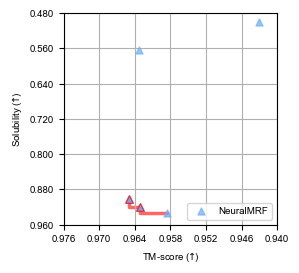

C:\Users\jianq\AppData\Local\Temp\ipykernel_42096\3401691120.py:83: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(f1[indics_selected], f2[indics_selected], **plt_args)


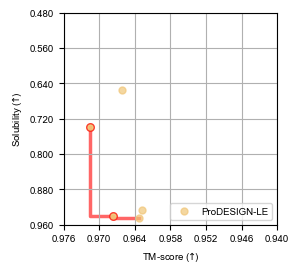

In [4]:
# plot the pareto front of the two methods in round1
csv_file = "data/r1_pareto_le.csv"
csv_data = read_csv_to_dict(csv_file)
plot_2d(np.array(csv_data['TM-score']), np.array(csv_data['Solubility']), csv_data['Express'], 'NeuralMRF', file = "round1-mrf-fix.svg",)

csv_file = "data/r1_pareto_mrf.csv"
csv_data = read_csv_to_dict(csv_file)
plot_2d(np.array(csv_data['TM-score']), np.array(csv_data['Solubility']), csv_data['Express'], 'ProDESIGN-LE', file = "round1-le-fix.svg")

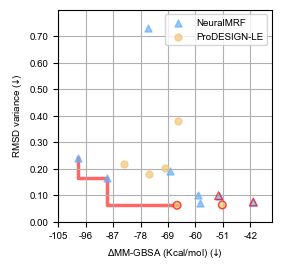

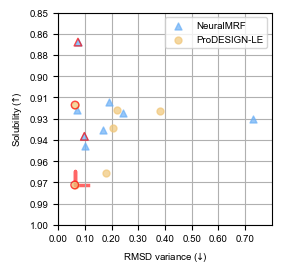

In [13]:
# plot the pareto front of the two methods in round2
fig_size = figsize_cm
fig_args = {"figsize":fig_size}
save_args = {"bbox_inches":'tight', "dpi":300}

csv_file = "data/r2_pareto.csv"
csv_data = read_csv_to_dict(csv_file)

method1_indics = [i for i in range(len(csv_data['Method'])) if csv_data['Method'][i] == "NeuralMRF"]
method2_indics = [i for i in range(len(csv_data['Method'])) if csv_data['Method'][i] == "ProDESIGN-LE"]
bind_indics = [i for i in range(len(csv_data['IgG-Binding'])) if csv_data['IgG-Binding'][i] != "/"]
pareto_indices = identify_pareto_front_3d(np.array(csv_data['MMGBS']).astype(float),
                                          np.array(csv_data['RMSD_VAR']).astype(float),
                                          np.array(csv_data['Solubility']).astype(float))

plot_3d(np.array(csv_data['MMGBS']).astype(float),
        np.array(csv_data['RMSD_VAR']).astype(float),
        np.array(csv_data['Solubility']).astype(float), 
        bind_indics,
        file = "round2", 
        method1_indics = method1_indics, 
        method2_indics = method2_indics, 
        pareto_indices=pareto_indices,
        labels = None, # if you want to label the points, set labels to csv_data['Name'] or other column in the csv file
       ) # , color = (254,6,0))


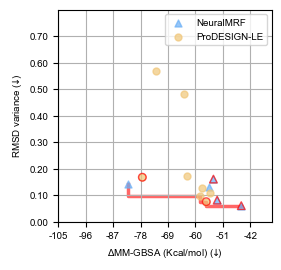

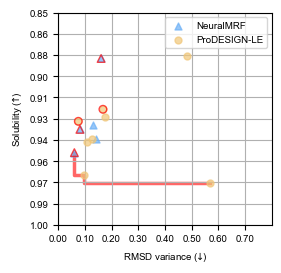

In [16]:
csv_file = "data/r3_pareto.csv"
# for PDN35, the MMGBS is -106.5, which is an outlier compared to other data points. We remove it when plotting the pareto front of round 3.
csv_data = read_csv_to_dict(csv_file, remove_outliers=True, outlier_column="Name", outlier_values=["PDN35"]) 

method1_indics = [i for i in range(len(csv_data['Method'])) if csv_data['Method'][i] == "NeuralMRF"]
method2_indics = [i for i in range(len(csv_data['Method'])) if csv_data['Method'][i] == "ProDESIGN-LE"]
bind_indics = [i for i in range(len(csv_data['IgG-Binding'])) if csv_data['IgG-Binding'][i] != "/"]
pareto_indices = identify_pareto_front_3d(np.array(csv_data['MMGBS']).astype(float),
                                          np.array(csv_data['RMSD_VAR']).astype(float),
                                          np.array(csv_data['Solubility']).astype(float))

plot_3d(np.array(csv_data['MMGBS']).astype(float),
        np.array(csv_data['RMSD_VAR']).astype(float),
        np.array(csv_data['Solubility']).astype(float), 
        bind_indics,
        file = "round2", 
        method1_indics = method1_indics, 
        method2_indics = method2_indics, 
        pareto_indices=pareto_indices,
        labels = None, # if you want to label the points, set labels to csv_data['Name'] or other column in the csv file
       ) # , color = (254,6,0))